# CIFAR-100 Image Classification Training
This notebook is used to train CIFAR-100 classification models on Google Colab.

In [1]:
# 1.Install dependencies
!pip install torch torchvision matplotlib

In [2]:
# 2.Clone GitHub repository
!git clone https://github.com/coraagg/Group-Assignment---OptiMates
%cd Group-Assignment---OptiMates

Cloning into 'Group-Assignment---OptiMates'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 111 (delta 56), reused 12 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 6.53 MiB | 13.39 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/Group-Assignment---OptiMates


In [3]:
# 3.Check available GPU
!nvidia-smi

Sat Mar 28 04:15:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# 4.CIFAR-100 Image Classification Experiment Training Script
%%writefile train.py
import argparse
import csv
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from utils import get_data_loader
from models import LinearModel, MLP, BasicCNN, OptimizedCNN

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_one_epoch(model, device, loader, optimizer, criterion, loss_type):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for data, target in loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        if loss_type == 'nll':
            output = F.log_softmax(output, dim=1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, pred = output.max(1)
        total += target.size(0)
        correct += pred.eq(target).sum().item()

    avg_loss = total_loss / len(loader)
    acc = 100.0 * correct / total
    return avg_loss, acc

def evaluate(model, device, loader, criterion, loss_type):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            if loss_type == 'nll':
                output = F.log_softmax(output, dim=1)
            loss = criterion(output, target)

            total_loss += loss.item()
            _, pred = output.max(1)
            total += target.size(0)
            correct += pred.eq(target).sum().item()

    avg_loss = total_loss / len(loader)
    acc = 100.0 * correct / total
    return avg_loss, acc

def build_experiment_name(args):
    name = f"{args.model}_bs{args.batch_size}_lr{args.lr}_ep{args.epochs}"
    if args.model == 'mlp':
        name += (
            f"_hs{args.hidden_size}"
            f"_layers{args.num_layers}"
            f"_act{args.activation}"
            f"_drop{args.dropout}"
            f"_wd{args.weight_decay}"
            f"_bn{int(args.use_batchnorm)}"
        )
    if args.augment:
        name += "_aug"
    if args.loss_type != 'ce':
        name += f"_loss{args.loss_type}"
    return name

class CustomLoss(nn.Module):
    def __init__(self, smoothing=0.1, num_classes=100):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, input, target):
        log_probs = F.log_softmax(input, dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--model', type=str, required=True, choices=['linear', 'mlp', 'basic_cnn', 'optimized_cnn'])
    parser.add_argument('--batch_size', type=int, default=64)
    parser.add_argument('--lr', type=float, default=0.001)
    parser.add_argument('--epochs', type=int, default=30)
    parser.add_argument('--augment', action='store_true')
    parser.add_argument('--log_dir', type=str, default='logs')
    parser.add_argument('--seed', type=int, default=42)
    parser.add_argument('--hidden_size', type=int, default=512)
    parser.add_argument('--num_layers', type=int, default=2)
    parser.add_argument('--activation', type=str, default='relu', choices=['relu', 'tanh'])
    parser.add_argument('--dropout', type=float, default=0.3)
    parser.add_argument('--weight_decay', type=float, default=0.0)
    parser.add_argument('--use_batchnorm', action='store_true')
    parser.add_argument('--loss_type', type=str, default='ce', choices=['ce', 'nll', 'custom'])

    args = parser.parse_args()

    set_seed(args.seed)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    train_loader, val_loader, test_loader = get_data_loader(
        batch_size=args.batch_size,
        augment=args.augment
    )

    if args.model == 'linear':
        model = LinearModel()
    elif args.model == 'mlp':
        hidden_sizes = [args.hidden_size] * args.num_layers
        model = MLP(
            hidden_sizes=hidden_sizes,
            activation=args.activation,
            dropout=args.dropout,
            use_batchnorm=args.use_batchnorm
        )
    elif args.model == 'basic_cnn':
        model = BasicCNN()
    else:
        model = OptimizedCNN()

    model = model.to(device)

    if args.loss_type == 'ce':
        criterion = nn.CrossEntropyLoss()
    elif args.loss_type == 'nll':
        criterion = nn.NLLLoss()
    elif args.loss_type == 'custom':
        criterion = CustomLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=args.lr,
        weight_decay=args.weight_decay
    )

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=10,
        gamma=0.5
    )

    os.makedirs(args.log_dir, exist_ok=True)

    exp_name = build_experiment_name(args)
    log_file = os.path.join(args.log_dir, f"{exp_name}.csv")
    best_model_path = os.path.join(args.log_dir, f"{exp_name}_best.pth")
    result_file = os.path.join(args.log_dir, "test_results.txt")

    with open(log_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'epoch',
            'train_loss',
            'train_acc',
            'val_loss',
            'val_acc',
            'lr'
        ])

    best_val_acc = 0.0

    for epoch in range(1, args.epochs + 1):
        train_loss, train_acc = train_one_epoch(model, device, train_loader, optimizer, criterion, args.loss_type)
        val_loss, val_acc = evaluate(model, device, val_loader, criterion, args.loss_type)

        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoch {epoch:02d}/{args.epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

        with open(log_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch,
                train_loss,
                train_acc,
                val_loss,
                val_acc,
                current_lr
            ])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

        scheduler.step()

    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    test_loss, test_acc = evaluate(model, device, test_loader, criterion, args.loss_type)

    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    with open(result_file, 'a', encoding='utf-8') as f:
        f.write(
            f"{exp_name} | "
            f"Best Val Acc={best_val_acc:.2f}% | "
            f"Test Acc={test_acc:.2f}%\n"
        )

if __name__ == '__main__':
    main()

Overwriting train.py


In [ ]:
# 4.Run training (Basic CNN)
!python train.py --model basic_cnn --epochs 30 --batch_size 64 --lr 0.001 --augment

Using device: cuda
100% 169M/169M [00:03<00:00, 49.4MB/s]
Epoch 01/30 | Train Loss: 4.1195, Train Acc: 6.58% | Val Loss: 3.6200, Val Acc: 13.16% | LR: 0.001000
Epoch 02/30 | Train Loss: 3.7736, Train Acc: 10.82% | Val Loss: 3.3594, Val Acc: 19.06% | LR: 0.001000
Epoch 03/30 | Train Loss: 3.6248, Train Acc: 12.83% | Val Loss: 3.2592, Val Acc: 21.35% | LR: 0.001000
Epoch 04/30 | Train Loss: 3.5322, Train Acc: 14.33% | Val Loss: 3.0928, Val Acc: 23.31% | LR: 0.001000
Epoch 05/30 | Train Loss: 3.4476, Train Acc: 15.65% | Val Loss: 3.0030, Val Acc: 25.33% | LR: 0.001000
Epoch 06/30 | Train Loss: 3.3681, Train Acc: 16.79% | Val Loss: 2.9483, Val Acc: 26.40% | LR: 0.001000
Epoch 07/30 | Train Loss: 3.3135, Train Acc: 17.82% | Val Loss: 2.8656, Val Acc: 27.39% | LR: 0.001000
Epoch 08/30 | Train Loss: 3.2886, Train Acc: 18.26% | Val Loss: 2.8520, Val Acc: 28.07% | LR: 0.001000
Epoch 09/30 | Train Loss: 3.2545, Train Acc: 18.70% | Val Loss: 2.8113, Val Acc: 28.42% | LR: 0.001000
Epoch 10/30 | Tr

In [5]:
# 5.Run training (Optimized CNN)
!python train.py --model optimized_cnn --epochs 50 --batch_size 128 --lr 0.01 --augment

Using device: cuda
100% 169M/169M [00:12<00:00, 13.1MB/s]
Epoch 01/50 | Train Loss: 4.2684, Train Acc: 4.69% | Val Loss: 4.0324, Val Acc: 7.08% | LR: 0.010000
Epoch 02/50 | Train Loss: 3.8720, Train Acc: 9.61% | Val Loss: 3.6971, Val Acc: 13.46% | LR: 0.010000
Epoch 03/50 | Train Loss: 3.6328, Train Acc: 13.48% | Val Loss: 3.3591, Val Acc: 18.66% | LR: 0.010000
Epoch 04/50 | Train Loss: 3.4363, Train Acc: 17.08% | Val Loss: 3.1482, Val Acc: 23.04% | LR: 0.010000
Epoch 05/50 | Train Loss: 3.2580, Train Acc: 20.28% | Val Loss: 3.0073, Val Acc: 26.22% | LR: 0.010000
Epoch 06/50 | Train Loss: 3.1057, Train Acc: 23.08% | Val Loss: 2.8945, Val Acc: 27.60% | LR: 0.010000
Epoch 07/50 | Train Loss: 2.9837, Train Acc: 25.52% | Val Loss: 2.7877, Val Acc: 29.99% | LR: 0.010000
Epoch 08/50 | Train Loss: 2.8616, Train Acc: 27.88% | Val Loss: 2.5648, Val Acc: 33.97% | LR: 0.010000
Epoch 09/50 | Train Loss: 2.7649, Train Acc: 29.67% | Val Loss: 2.4680, Val Acc: 36.20% | LR: 0.010000
Epoch 10/50 | Trai

In [6]:
# 6.Nine sets of comparative experiments
# Loss - NLLLoss
!python train.py --model optimized_cnn --batch_size 128 --lr 0.01 --epochs 50 --augment --loss_type nll

# Loss - CustomLoss
!python train.py --model optimized_cnn --batch_size 128 --lr 0.01 --epochs 50 --augment --loss_type custom

# Learning rate - 0.1
!python train.py --model optimized_cnn --batch_size 128 --lr 0.1 --epochs 50 --augment --loss_type ce

# Learning rate - 0.001
!python train.py --model optimized_cnn --batch_size 128 --lr 0.001 --epochs 50 --augment --loss_type ce

# Learning rate - 0.0001
!python train.py --model optimized_cnn --batch_size 128 --lr 0.0001 --epochs 50 --augment --loss_type ce

# Batch size - 8
!python train.py --model optimized_cnn --batch_size 8 --lr 0.01 --epochs 50 --augment --loss_type ce

# Batch size - 16
# !python train.py --model optimized_cnn --batch_size 16 --lr 0.01 --epochs 50 --augment --loss_type ce

# Batch size - 32
# !python train.py --model optimized_cnn --batch_size 32 --lr 0.01 --epochs 50 --augment --loss_type ce

# Batch size - 64
# !python train.py --model optimized_cnn --batch_size 64 --lr 0.01 --epochs 50 --augment --loss_type ce

Using device: cuda
Epoch 01/50 | Train Loss: 4.2684, Train Acc: 4.69% | Val Loss: 4.0324, Val Acc: 7.08% | LR: 0.010000
Epoch 02/50 | Train Loss: 3.8720, Train Acc: 9.61% | Val Loss: 3.6971, Val Acc: 13.46% | LR: 0.010000
Epoch 03/50 | Train Loss: 3.6328, Train Acc: 13.48% | Val Loss: 3.3591, Val Acc: 18.66% | LR: 0.010000
Epoch 04/50 | Train Loss: 3.4363, Train Acc: 17.08% | Val Loss: 3.1482, Val Acc: 23.04% | LR: 0.010000
Epoch 05/50 | Train Loss: 3.2580, Train Acc: 20.28% | Val Loss: 3.0073, Val Acc: 26.22% | LR: 0.010000
Epoch 06/50 | Train Loss: 3.1057, Train Acc: 23.08% | Val Loss: 2.8945, Val Acc: 27.60% | LR: 0.010000
Epoch 07/50 | Train Loss: 2.9837, Train Acc: 25.52% | Val Loss: 2.7877, Val Acc: 29.99% | LR: 0.010000
Epoch 08/50 | Train Loss: 2.8616, Train Acc: 27.88% | Val Loss: 2.5648, Val Acc: 33.97% | LR: 0.010000
Epoch 09/50 | Train Loss: 2.7649, Train Acc: 29.67% | Val Loss: 2.4680, Val Acc: 36.20% | LR: 0.010000
Epoch 10/50 | Train Loss: 2.6672, Train Acc: 31.82% | Val

In [9]:
# Batch size - 16
!python train.py --model optimized_cnn --batch_size 16 --lr 0.01 --epochs 50 --augment --loss_type ce

Using device: cuda
Epoch 01/50 | Train Loss: 4.3496, Train Acc: 3.83% | Val Loss: 3.9368, Val Acc: 8.38% | LR: 0.010000
Epoch 02/50 | Train Loss: 3.9565, Train Acc: 8.53% | Val Loss: 3.6288, Val Acc: 14.06% | LR: 0.010000
Epoch 03/50 | Train Loss: 3.7337, Train Acc: 12.15% | Val Loss: 3.4050, Val Acc: 17.61% | LR: 0.010000
Epoch 04/50 | Train Loss: 3.5610, Train Acc: 15.55% | Val Loss: 3.1908, Val Acc: 22.11% | LR: 0.010000
Epoch 05/50 | Train Loss: 3.4357, Train Acc: 17.54% | Val Loss: 3.0681, Val Acc: 24.55% | LR: 0.010000
Epoch 06/50 | Train Loss: 3.3276, Train Acc: 19.57% | Val Loss: 2.9649, Val Acc: 26.09% | LR: 0.010000
Epoch 07/50 | Train Loss: 3.2416, Train Acc: 21.01% | Val Loss: 2.8583, Val Acc: 28.89% | LR: 0.010000
Epoch 08/50 | Train Loss: 3.1757, Train Acc: 22.19% | Val Loss: 2.7531, Val Acc: 30.72% | LR: 0.010000
Epoch 09/50 | Train Loss: 3.1062, Train Acc: 23.75% | Val Loss: 2.6985, Val Acc: 31.45% | LR: 0.010000
Epoch 10/50 | Train Loss: 3.0480, Train Acc: 24.89% | Val

In [10]:
# Batch size - 32
!python train.py --model optimized_cnn --batch_size 32 --lr 0.01 --epochs 50 --augment --loss_type ce

Using device: cuda
Epoch 01/50 | Train Loss: 4.3103, Train Acc: 4.25% | Val Loss: 3.9580, Val Acc: 7.56% | LR: 0.010000
Epoch 02/50 | Train Loss: 3.9114, Train Acc: 9.39% | Val Loss: 3.5855, Val Acc: 14.61% | LR: 0.010000
Epoch 03/50 | Train Loss: 3.6783, Train Acc: 12.97% | Val Loss: 3.4067, Val Acc: 17.74% | LR: 0.010000
Epoch 04/50 | Train Loss: 3.4914, Train Acc: 16.19% | Val Loss: 3.1341, Val Acc: 22.91% | LR: 0.010000
Epoch 05/50 | Train Loss: 3.3622, Train Acc: 18.91% | Val Loss: 3.0212, Val Acc: 26.09% | LR: 0.010000
Epoch 06/50 | Train Loss: 3.2533, Train Acc: 20.89% | Val Loss: 2.9302, Val Acc: 27.09% | LR: 0.010000
Epoch 07/50 | Train Loss: 3.1670, Train Acc: 22.23% | Val Loss: 2.8189, Val Acc: 29.74% | LR: 0.010000
Epoch 08/50 | Train Loss: 3.0845, Train Acc: 23.66% | Val Loss: 2.7307, Val Acc: 31.28% | LR: 0.010000
Epoch 09/50 | Train Loss: 3.0187, Train Acc: 25.08% | Val Loss: 2.6649, Val Acc: 32.39% | LR: 0.010000
Epoch 10/50 | Train Loss: 2.9463, Train Acc: 26.70% | Val

In [11]:
# Batch size - 64
!python train.py --model optimized_cnn --batch_size 64 --lr 0.01 --epochs 50 --augment --loss_type ce

Using device: cuda
Epoch 01/50 | Train Loss: 4.2699, Train Acc: 4.66% | Val Loss: 3.8985, Val Acc: 8.79% | LR: 0.010000
Epoch 02/50 | Train Loss: 3.8768, Train Acc: 9.63% | Val Loss: 3.6038, Val Acc: 15.34% | LR: 0.010000
Epoch 03/50 | Train Loss: 3.6536, Train Acc: 13.45% | Val Loss: 3.3694, Val Acc: 18.48% | LR: 0.010000
Epoch 04/50 | Train Loss: 3.4584, Train Acc: 16.70% | Val Loss: 3.1651, Val Acc: 22.49% | LR: 0.010000
Epoch 05/50 | Train Loss: 3.2863, Train Acc: 20.36% | Val Loss: 2.9894, Val Acc: 26.50% | LR: 0.010000
Epoch 06/50 | Train Loss: 3.1209, Train Acc: 23.14% | Val Loss: 2.8288, Val Acc: 29.29% | LR: 0.010000
Epoch 07/50 | Train Loss: 2.9961, Train Acc: 25.36% | Val Loss: 2.6651, Val Acc: 32.24% | LR: 0.010000
Epoch 08/50 | Train Loss: 2.8640, Train Acc: 27.66% | Val Loss: 2.5796, Val Acc: 33.90% | LR: 0.010000
Epoch 09/50 | Train Loss: 2.7753, Train Acc: 29.74% | Val Loss: 2.4515, Val Acc: 37.41% | LR: 0.010000
Epoch 10/50 | Train Loss: 2.6772, Train Acc: 31.48% | Val

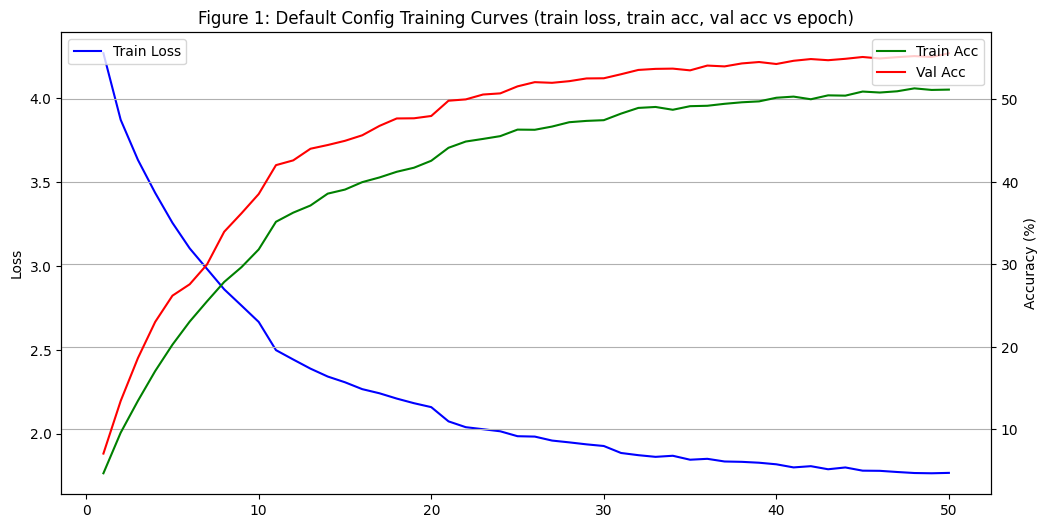

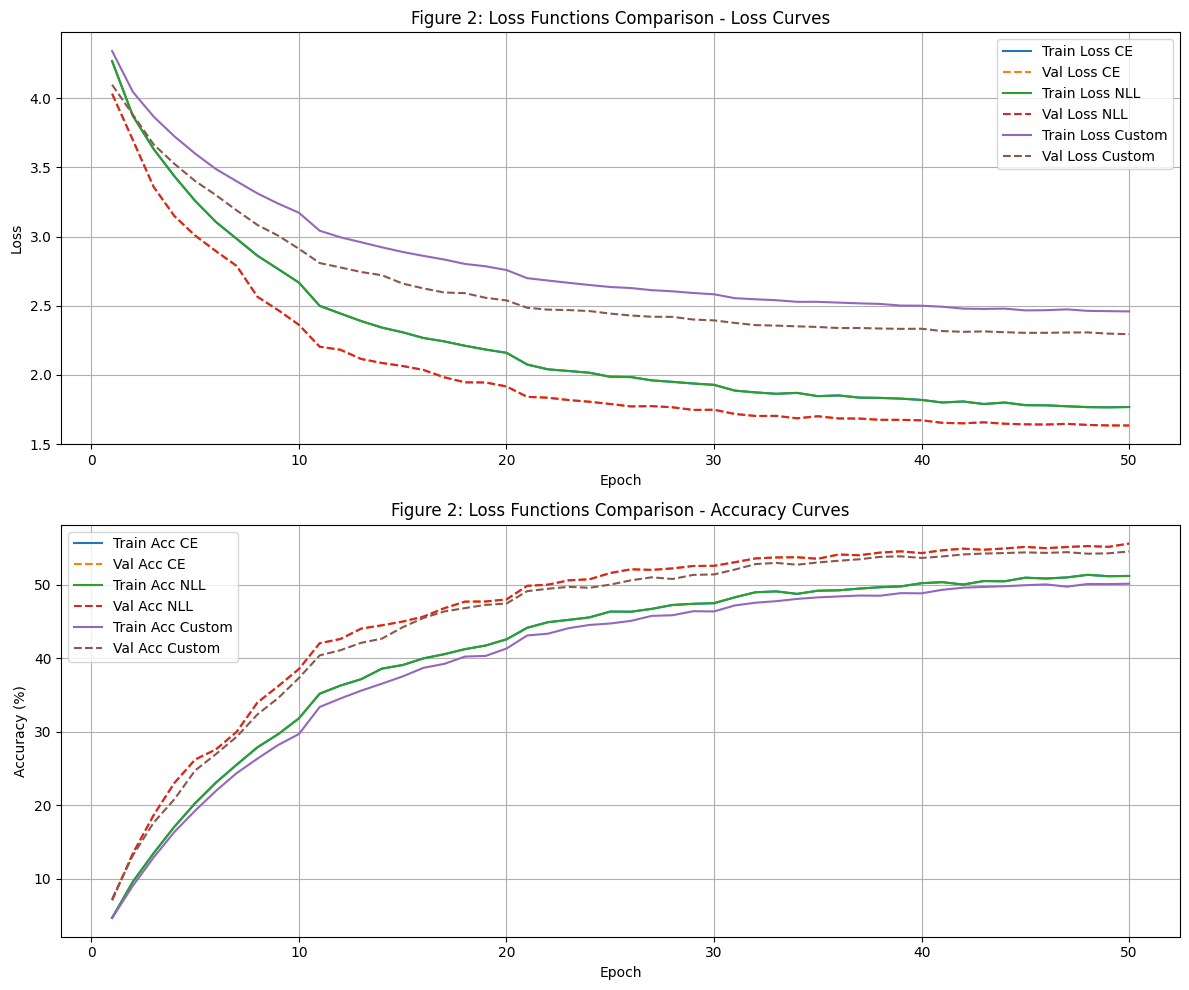

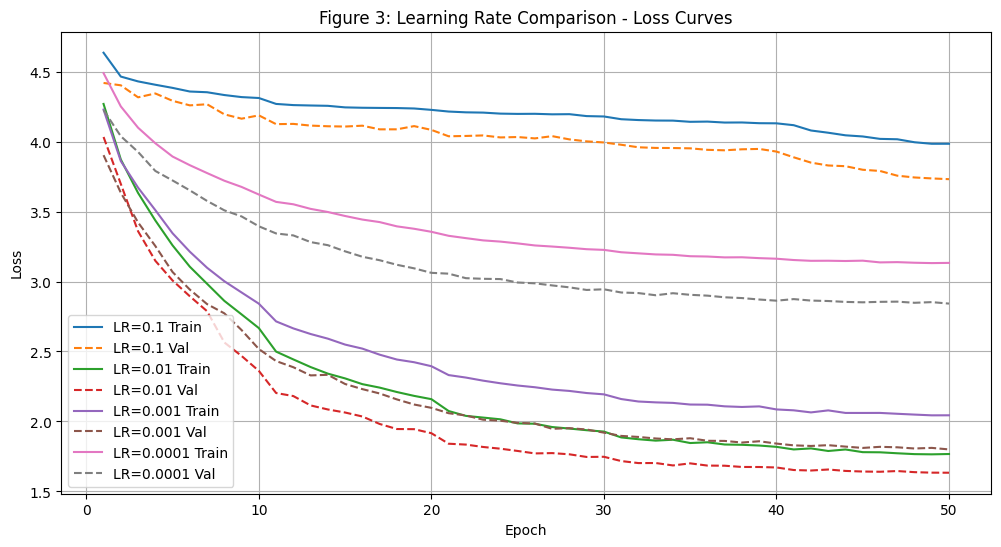

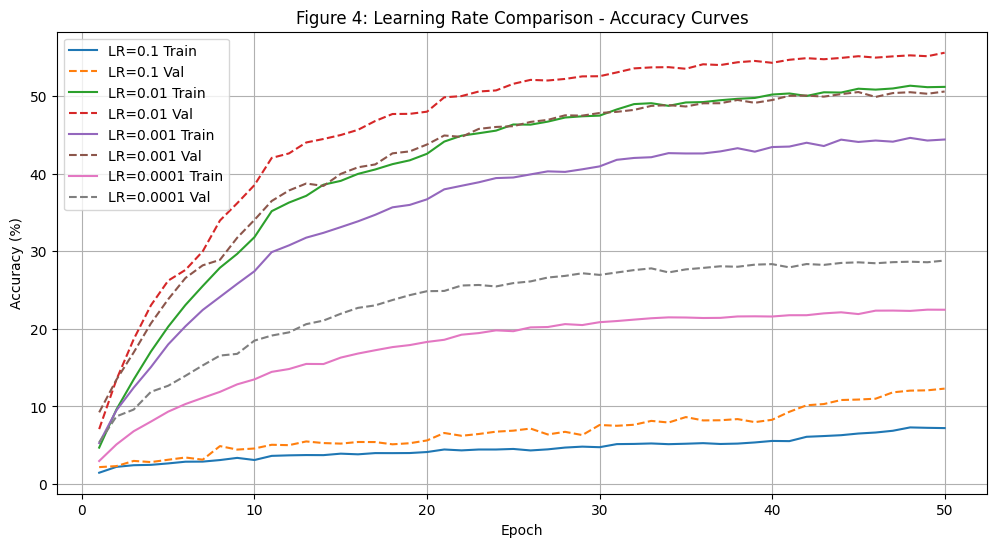

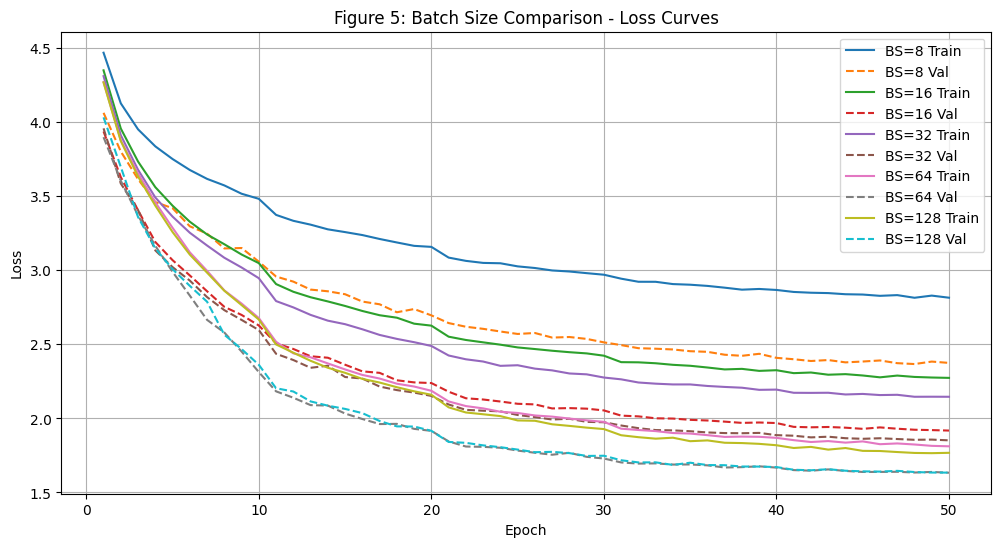

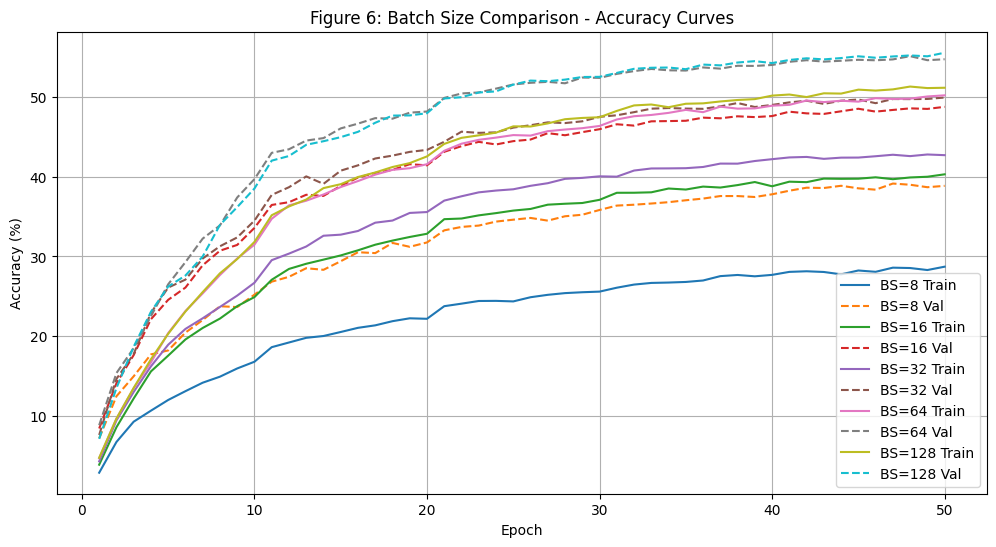

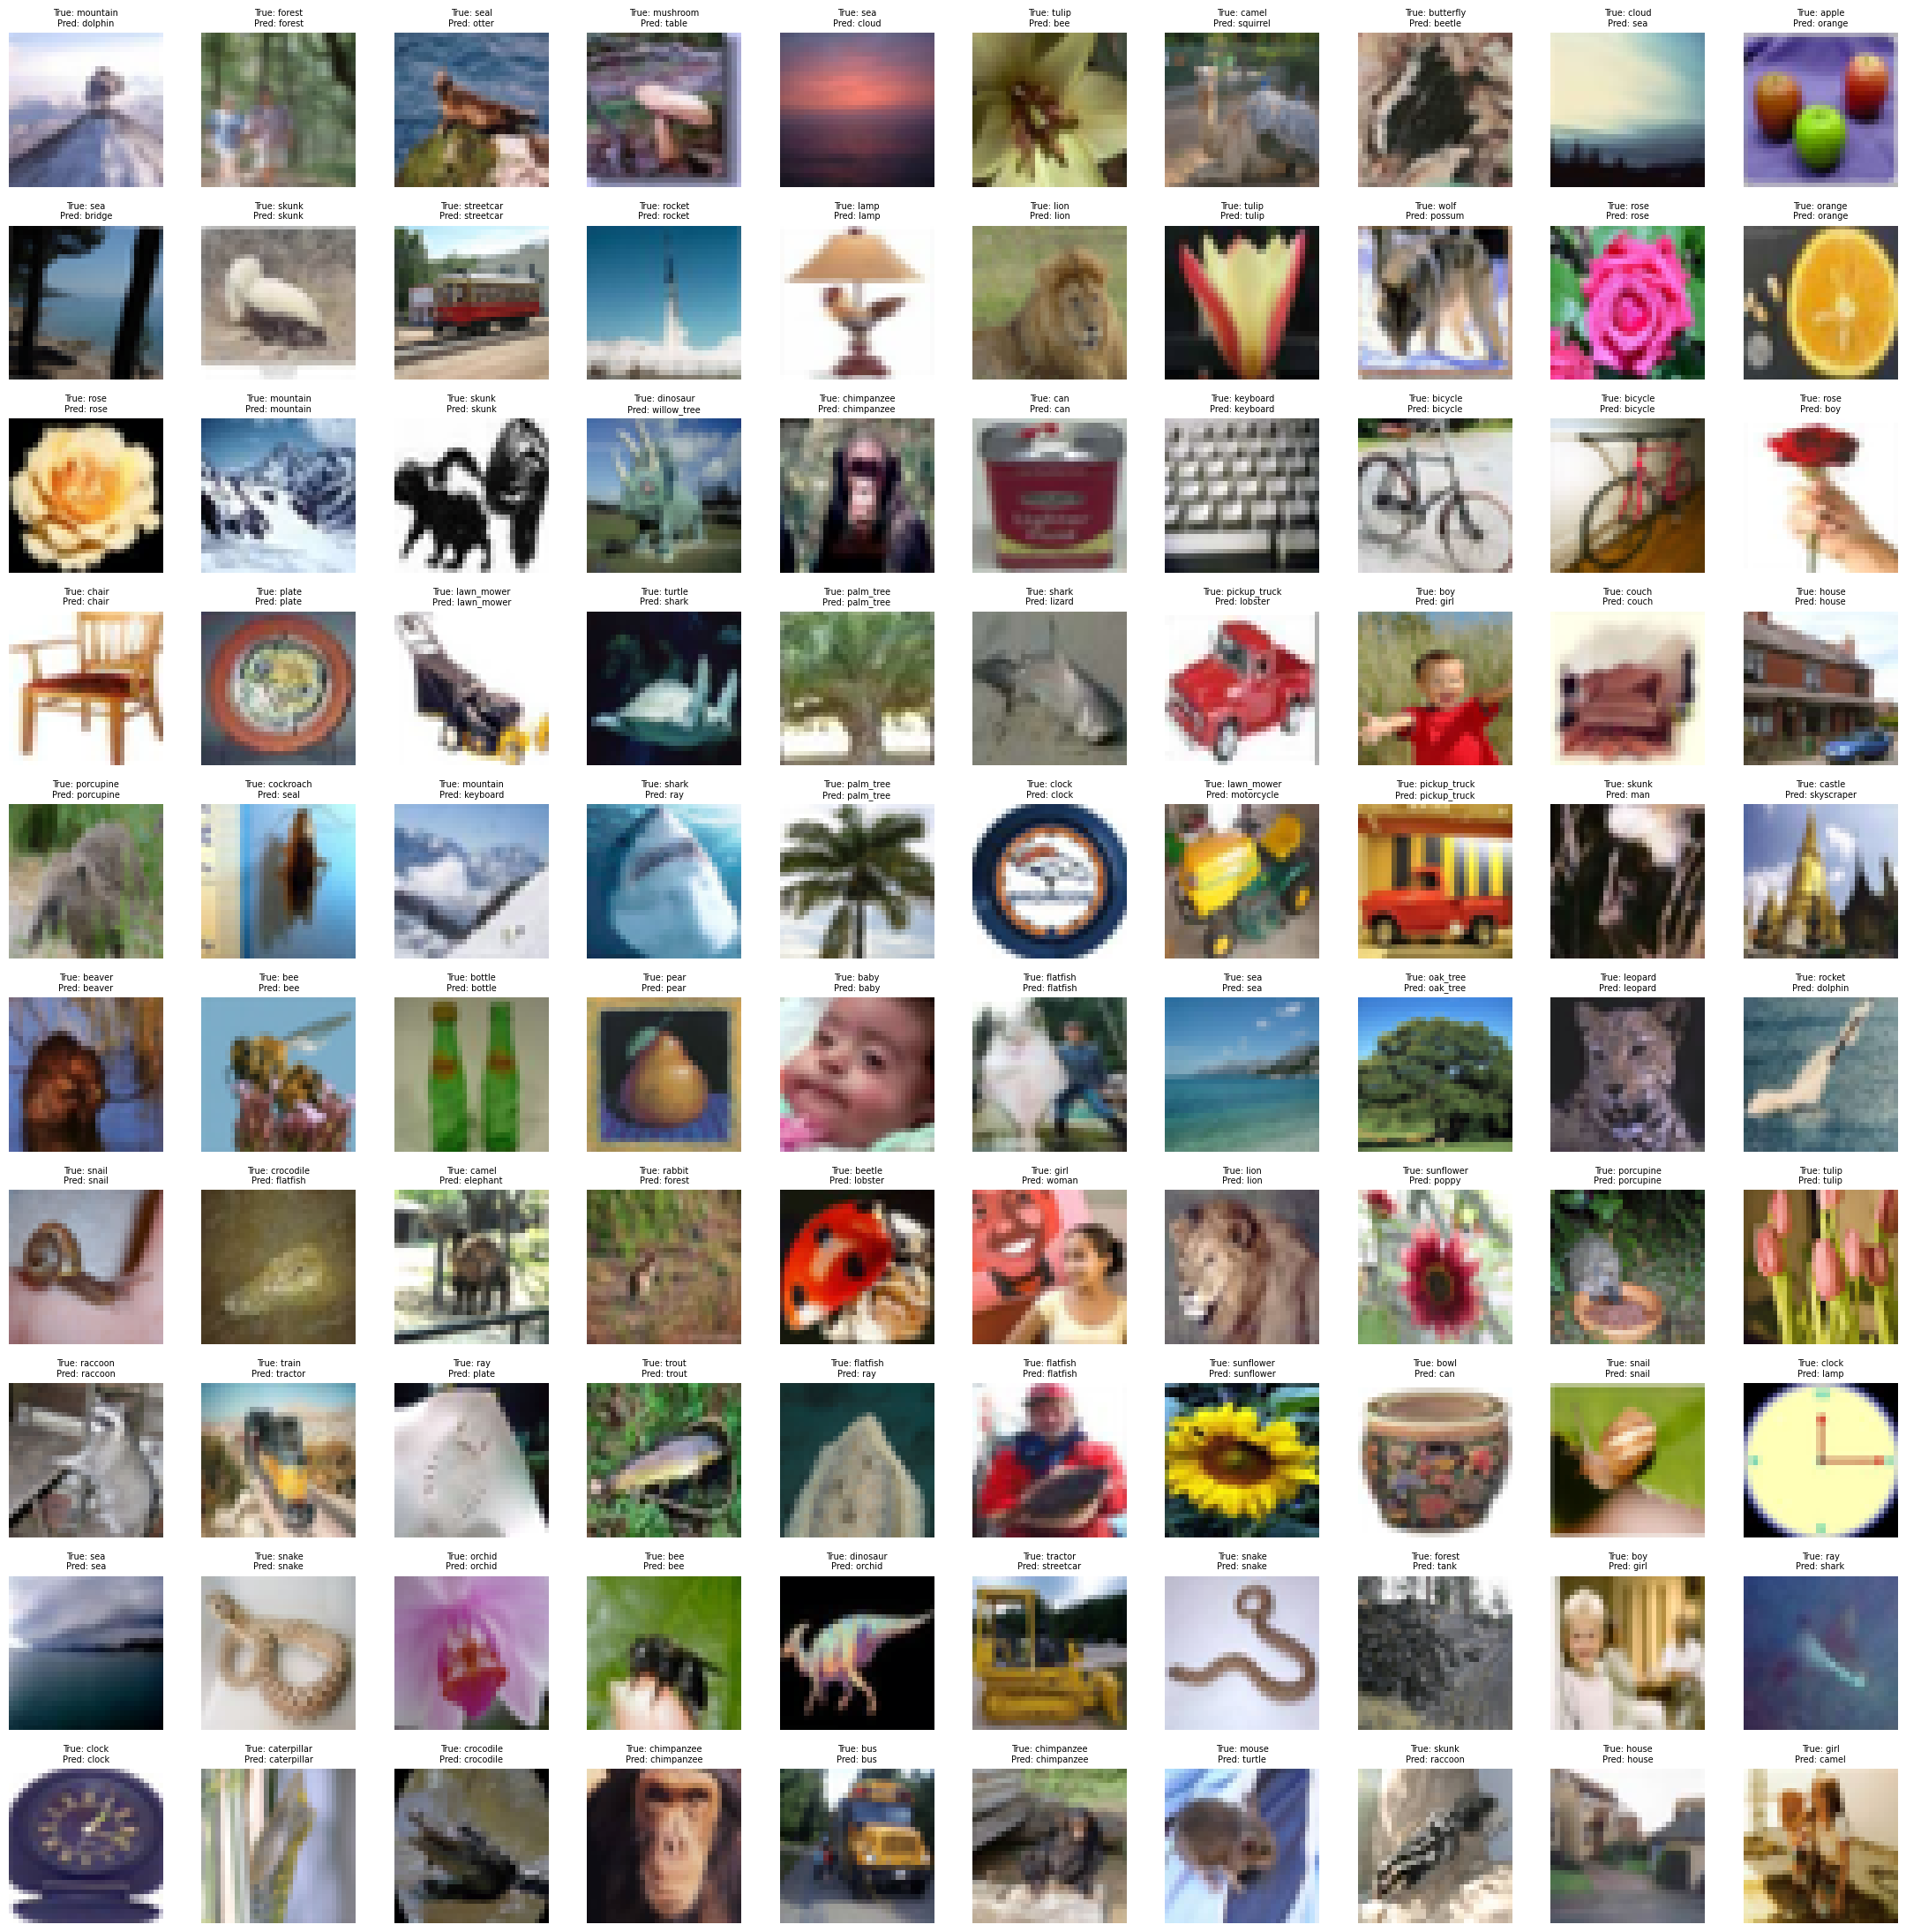

All seven charts have been generated and saved as fig1_default.png to fig7_predictions_100_samples.png.


In [12]:
# 7.Create charts
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.datasets as datasets
from utils import get_data_loader
from models import OptimizedCNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------- Fig1 --------------------------
df1 = pd.read_csv('logs/optimized_cnn_bs128_lr0.01_ep50_aug.csv')
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax1.plot(df1['epoch'], df1['train_loss'], label='Train Loss', color='blue')
ax1.set_ylabel('Loss')
ax2 = ax1.twinx()
ax2.plot(df1['epoch'], df1['train_acc'], label='Train Acc', color='green')
ax2.plot(df1['epoch'], df1['val_acc'], label='Val Acc', color='red')
ax2.set_ylabel('Accuracy (%)')
plt.title('Figure 1: Default Config Training Curves (train loss, train acc, val acc vs epoch)')
plt.xlabel('Epoch')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True)
plt.savefig('fig1_default.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------- Fig2 (Different loss functions, one picture) --------------------------
loss_files = [
    ('CE', 'optimized_cnn_bs128_lr0.01_ep50_aug.csv'),
    ('NLL', 'optimized_cnn_bs128_lr0.01_ep50_aug_lossnll.csv'),
    ('Custom', 'optimized_cnn_bs128_lr0.01_ep50_aug_losscustom.csv')
]
fig, axs = plt.subplots(2, 1, figsize=(12, 10))
for name, fname in loss_files:
    df = pd.read_csv(f'logs/{fname}')
    axs[0].plot(df['epoch'], df['train_loss'], label=f'Train Loss {name}')
    axs[0].plot(df['epoch'], df['val_loss'], label=f'Val Loss {name}', linestyle='--')
    axs[1].plot(df['epoch'], df['train_acc'], label=f'Train Acc {name}')
    axs[1].plot(df['epoch'], df['val_acc'], label=f'Val Acc {name}', linestyle='--')
axs[0].set_title('Figure 2: Loss Functions Comparison - Loss Curves')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)
axs[1].set_title('Figure 2: Loss Functions Comparison - Accuracy Curves')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.savefig('fig2_loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------- Fig3-4 (Different learning rates) --------------------------
lrs = [0.1, 0.01, 0.001, 0.0001]
lr_files = [f'optimized_cnn_bs128_lr{lr}_ep50_aug.csv' for lr in lrs]

plt.figure(figsize=(12, 6))
for lr, fname in zip(lrs, lr_files):
    df = pd.read_csv(f'logs/{fname}')
    plt.plot(df['epoch'], df['train_loss'], label=f'LR={lr} Train')
    plt.plot(df['epoch'], df['val_loss'], label=f'LR={lr} Val', linestyle='--')
plt.title('Figure 3: Learning Rate Comparison - Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('fig3_lr_loss.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
for lr, fname in zip(lrs, lr_files):
    df = pd.read_csv(f'logs/{fname}')
    plt.plot(df['epoch'], df['train_acc'], label=f'LR={lr} Train')
    plt.plot(df['epoch'], df['val_acc'], label=f'LR={lr} Val', linestyle='--')
plt.title('Figure 4: Learning Rate Comparison - Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.savefig('fig4_lr_acc.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------- Fig5-6 (Different batch sizes) --------------------------
bss = [8, 16, 32, 64, 128]
bs_files = [f'optimized_cnn_bs{bs}_lr0.01_ep50_aug.csv' for bs in bss]

plt.figure(figsize=(12, 6))
for bs, fname in zip(bss, bs_files):
    df = pd.read_csv(f'logs/{fname}')
    plt.plot(df['epoch'], df['train_loss'], label=f'BS={bs} Train')
    plt.plot(df['epoch'], df['val_loss'], label=f'BS={bs} Val', linestyle='--')
plt.title('Figure 5: Batch Size Comparison - Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('fig5_bs_loss.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
for bs, fname in zip(bss, bs_files):
    df = pd.read_csv(f'logs/{fname}')
    plt.plot(df['epoch'], df['train_acc'], label=f'BS={bs} Train')
    plt.plot(df['epoch'], df['val_acc'], label=f'BS={bs} Val', linestyle='--')
plt.title('Figure 6: Batch Size Comparison - Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.savefig('fig6_bs_acc.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------- Fig7 (The prediction results of the first 100 test samples) --------------------------
_, _, test_loader = get_data_loader(batch_size=64, augment=False)

model = OptimizedCNN()
model.load_state_dict(torch.load('logs/optimized_cnn_bs128_lr0.01_ep50_aug_best.pth', map_location=device))
model = model.to(device)
model.eval()

images = []
true_labels = []
pred_labels = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        output = model(data)
        preds = output.argmax(dim=1)
        for i in range(data.size(0)):
            if len(images) >= 100:
                break
            images.append(data[i].cpu())
            true_labels.append(target[i].item())
            pred_labels.append(preds[i].item())
        if len(images) >= 100:
            break

mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
def denorm(img):
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

cifar100_classes = datasets.CIFAR100(root='./data', train=False, download=False).classes

fig, axs = plt.subplots(10, 10, figsize=(22, 22))
for i in range(100):
    row, col = i // 10, i % 10
    img = denorm(images[i])
    true_name = cifar100_classes[true_labels[i]]
    pred_name = cifar100_classes[pred_labels[i]]
    axs[row, col].imshow(img)
    axs[row, col].set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=7)
    axs[row, col].axis('off')
plt.tight_layout()
plt.savefig('fig7_predictions_100_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print("All seven charts have been generated and saved as fig1_default.png to fig7_predictions_100_samples.png.")

In [7]:
import os
from google.colab import files

%cd /content/Group-Assignment---OptiMates

print("Packing logs folder and all figures...")
!zip -r my_project_backup.zip logs/ fig*.png 2>/dev/null || echo "Some files may not exist, that's fine"

if os.path.exists("my_project_backup.zip"):
    files.download("my_project_backup.zip")
    print("✅ Packaging complete! Please download my_project_backup.zip")
    print("It contains all currently generated CSV, best.pth and figure files")
else:
    print("⚠️ No files found, please check the logs folder")

/content/Group-Assignment---OptiMates
Packing logs folder and all figures...
	zip warning: name not matched: fig*.png
  adding: logs/ (stored 0%)
  adding: logs/optimized_cnn_bs8_lr0.01_ep50_aug_best.pth (deflated 7%)
  adding: logs/basic_cnn_bs64_lr0.001_ep30_aug_best.pth (deflated 8%)
  adding: logs/final_mlp_results.csv (deflated 71%)
  adding: logs/optimized_cnn_bs128_lr0.01_ep50_aug_losscustom.csv (deflated 54%)
  adding: logs/optimized_cnn_bs128_lr0.001_ep50_aug_best.pth (deflated 8%)
  adding: logs/optimized_cnn_bs128_lr0.01_ep50_aug_lossnll.csv (deflated 54%)
  adding: logs/optimized_cnn_bs128_lr0.01_ep50_aug_lossnll_best.pth (deflated 8%)
  adding: logs/optimized_cnn_bs64_lr0.01_ep50_aug_best.pth (deflated 8%)
  adding: logs/test_results.txt (deflated 72%)
  adding: logs/optimized_cnn_bs32_lr0.01_ep50_aug_best.pth (deflated 7%)
  adding: logs/basic_cnn_bs64_lr0.001_ep30_aug.csv (deflated 54%)
  adding: logs/optimized_cnn_bs128_lr0.01_ep50_aug_best.pth (deflated 8%)
  adding: l

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Packaging complete! Please download my_project_backup.zip
It contains all currently generated CSV, best.pth and figure files


## After training, download logs and models

In [ ]:
import os
import glob
from google.colab import files

best_models = glob.glob('logs/*_best.pth')
if best_models:
    for model_file in best_models:
        print(f"Downloading {model_file}")
        files.download(model_file)
else:
    print("No best model file found. Please check the logs directory.")
    print("Files in logs:", os.listdir('logs'))

for csv_file in glob.glob('logs/*.csv'):
    print(f"Downloading {csv_file}")
    files.download(csv_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>